In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scanpy as sc
import gseapy
import seaborn as sns
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42


In [3]:
DE = pd.read_csv('../data/ASXL_vs_JAK2_DE_1_BC002.csv', index_col=0)
pre_res = gseapy.prerank(DE.loc[:,['primerid', 'coef']], gene_sets='MSigDB_Hallmark_2020', verbose=True)
res = pre_res.res2d.copy()

2026-04-12 17:19:26,275 [WARNING] Input gene rankings contains NA values(gene name and ranking value), drop them all!
2026-04-12 17:19:26,283 [INFO] Parsing data files for GSEA.............................
2026-04-12 17:19:26,294 [INFO] Enrichr library gene sets already downloaded in: /home/blattms1/.cache/gseapy, use local file
2026-04-12 17:19:26,299 [INFO] 0001 gene_sets have been filtered out when max_size=500 and min_size=15
2026-04-12 17:19:26,300 [INFO] 0049 gene_sets used for further statistical testing.....


2026-04-12 17:19:26,300 [INFO] Start to run GSEA...Might take a while..................
2026-04-12 17:19:27,263 [INFO] Congratulations. GSEApy runs successfully................



In [4]:
res.loc[res['FDR q-val'] < 0.1].sort_values('NES', ascending=False).iloc[0:2]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
5,prerank,TGF-beta Signaling,0.66105,1.567173,0.004754,0.065019,0.061,18/49,13.26%,THBS1;ENG;SKIL;PPM1A;NCOR2;SMAD3;SKI;CTNNB1;ID...
6,prerank,TNF-alpha Signaling via NF-kB,0.535497,1.542789,0.0,0.047014,0.086,67/188,11.15%,BTG1;G0S2;OLR1;ABCA1;CEBPD;RNF19B;RIPK2;NR4A1;...


In [5]:
res.loc[res['FDR q-val'] < 0.1].sort_values('NES', ascending=True).iloc[0:2]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Interferon Gamma Response,-0.816932,-2.441159,0.0,0.0,0.0,94/187,6.24%,SERPING1;IFITM3;WARS1;FGL2;UBE2L6;VAMP5;LY6E;C...
1,prerank,Interferon Alpha Response,-0.847055,-2.355725,0.0,0.0,0.0,40/93,4.44%,IFITM3;WARS1;UBE2L6;LY6E;CD74;SELL;IFI27;TAP1;...


TGF-beta Signaling
TNF-alpha Signaling via NF-kB
Interferon Gamma Response
Interferon Alpha Response


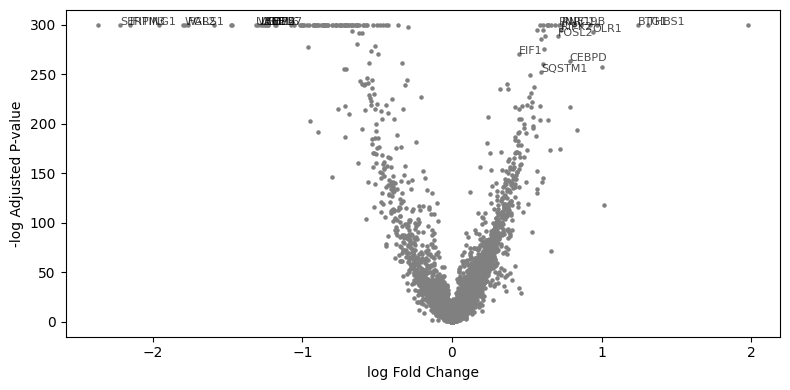

In [6]:
s=10
df = DE.copy()

df['Pr(>Chisq)'] = df['Pr(>Chisq)'] + (1e-300)
fig,ax = plt.subplots(figsize=(8,4))
ax.scatter(df['coef'], -np.log10(df['Pr(>Chisq)']), s=5, color='grey')

pathway_genes = res.sort_values('NES', ascending=False).iloc[0]['Lead_genes'].split(';')
pathway_genes.extend(res.sort_values('NES', ascending=False).iloc[1]['Lead_genes'].split(';'))
pathway_genes = list(set(pathway_genes))

print(res.sort_values('NES', ascending=False).iloc[0]['Term'])
print(res.sort_values('NES', ascending=False).iloc[1]['Term'])

pathway_genes = df.loc[df['primerid'].isin(pathway_genes)].sort_values(['Pr(>Chisq)','coef'], ascending=[True,False]).iloc[0:10]['primerid'].values
for gene in pathway_genes:
    sub = df.loc[df['primerid'] == gene]
    ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7)

### now plot downregulated genes
pathway_genes = res.sort_values('NES', ascending=True).iloc[0]['Lead_genes'].split(';')
pathway_genes.extend(res.sort_values('NES', ascending=True).iloc[1]['Lead_genes'].split(';'))
pathway_genes = list(set(pathway_genes))

print(res.sort_values('NES', ascending=True).iloc[0]['Term'])
print(res.sort_values('NES', ascending=True).iloc[1]['Term'])

pathway_genes = df.loc[df['primerid'].isin(pathway_genes)].sort_values(['Pr(>Chisq)','coef'], ascending=[True,True]).iloc[0:10]['primerid'].values
for gene in pathway_genes:
    sub = df.loc[df['primerid'] == gene]
    ax.text(sub['coef'].values[0], -np.log10(sub['Pr(>Chisq)'].values[0]), gene, fontsize=8, alpha=0.7)


ax.set_xlabel('log Fold Change')
ax.set_ylabel('-log Adjusted P-value')
plt.tight_layout()
plt.savefig('../plots/volcano_BC002_1.pdf')
